In [5]:
import numpy as np
from numpy.fft import ifft, ifftshift
import matplotlib.pyplot as plt


fa = 128e3      # frequência de amostragem (samp_rate)
sps = 16        # número de amostras por símbolo
fs = fa / 16    # frequência de sinalização (frequência de símbolos)
Ts = 1 / fs     # período de sinalização (período de símbolos)
Ntaps = 256     # número de coeficientes dos filtros FIR projetados

# Parâmetros da fibra:
D = 17e-6            # coeficiente de dispersão cromática da fibra (s/m^2)
lambda_ = 1550e-9    # comprimento de onda da portadora(m)
c = 3e5              # velocidade da luz no vácuo (km/s)
beta2 = D * lambda_**2 / (2 * np.pi * c)  # parâmetro de dispersão cromática

# Vetor de frequências do sinal
omega = 2 * np.pi * np.linspace(-0.5, 0.5, Ntaps) * (fa / 16) * 1e6

# Lista com as distâncias do roteiro
distancias = [1500, 3000, 4000, 8000]

print("Iniciando a geração dos filtros e gráficos...")


for L in distancias:
    print(f"\nProcessando L = {L} km...")
    
    # 1. Resposta em frequência e ao impulso do Canal
    Hcd = np.exp(1j * (beta2 / 2) * L * omega**2)
    hcd_fir = ifftshift(ifft(Hcd))

    # 2. Resposta em frequência e ao impulso do Equalizador ZF
    Hcd_zf = 1 / Hcd
    hcd_zf_fir = ifftshift(ifft(Hcd_zf))


    plt.figure(figsize=(12, 5))

    # Subplot 1: Valor Absoluto
    plt.subplot(1, 2, 1)
    plt.plot(np.abs(hcd_fir), '-*', label='Canal')
    plt.plot(np.abs(hcd_zf_fir), '-o', label='Equalizador ZF')
    plt.xlim([0, Ntaps - 1])
    plt.title(f'Valor absoluto da resposta ao impulso (L={L}km)')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Fase
    plt.subplot(1, 2, 2)
    plt.plot(np.unwrap(np.angle(hcd_fir)), '-*', label='Canal')
    plt.plot(np.unwrap(np.angle(hcd_zf_fir)), '-o', label='Equalizador ZF')
    plt.xlim([0, Ntaps - 1])
    plt.title(f'Fase da resposta ao impulso (L={L}km)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    
    # Salva o gráfico como imagem PNG
    nome_imagem = f'Exp5_Grafico_L={L}km.png'
    plt.savefig(nome_imagem, dpi=300) # dpi=300 garante alta qualidade para o relatório
    plt.close() # Fecha a figura atual para liberar memória antes da próxima iteração
    print(f"  -> Gráfico salvo: {nome_imagem}")

    
    nome_txt = f'Exp5_L={L}km.txt'
    
    with open(nome_txt, 'w') as fileID:
        fileID.write(f'\n\nCoeficientes do filtro de dispersao cromatica para {L} km:\n\n[')
        
        canal_str = []
        for val in hcd_fir:
            sign = '+' if val.imag >= 0 else '-'
            canal_str.append(f'{val.real:.6f}{sign}{abs(val.imag):.6f}j')
        fileID.write(', '.join(canal_str) + ']\n\n')

        fileID.write(f'\n\nCoeficientes do filtro de equalizador zero-forcing para {L} km:\n\n[')
        
        zf_str = []
        for val in hcd_zf_fir:
            sign = '+' if val.imag >= 0 else '-'
            zf_str.append(f'{val.real:.6f}{sign}{abs(val.imag):.6f}j')
        fileID.write(', '.join(zf_str) + ']\n')
        
    print(f"  -> Coeficientes salvos: {nome_txt}")

print("\nProcesso concluído com sucesso! Verifique a pasta onde o script está salvo.")

Iniciando a geração dos filtros e gráficos...

Processando L = 1500 km...
  -> Gráfico salvo: Exp5_Grafico_L=1500km.png
  -> Coeficientes salvos: Exp5_L=1500km.txt

Processando L = 3000 km...
  -> Gráfico salvo: Exp5_Grafico_L=3000km.png
  -> Coeficientes salvos: Exp5_L=3000km.txt

Processando L = 4000 km...
  -> Gráfico salvo: Exp5_Grafico_L=4000km.png
  -> Coeficientes salvos: Exp5_L=4000km.txt

Processando L = 8000 km...
  -> Gráfico salvo: Exp5_Grafico_L=8000km.png
  -> Coeficientes salvos: Exp5_L=8000km.txt

Processo concluído com sucesso! Verifique a pasta onde o script está salvo.


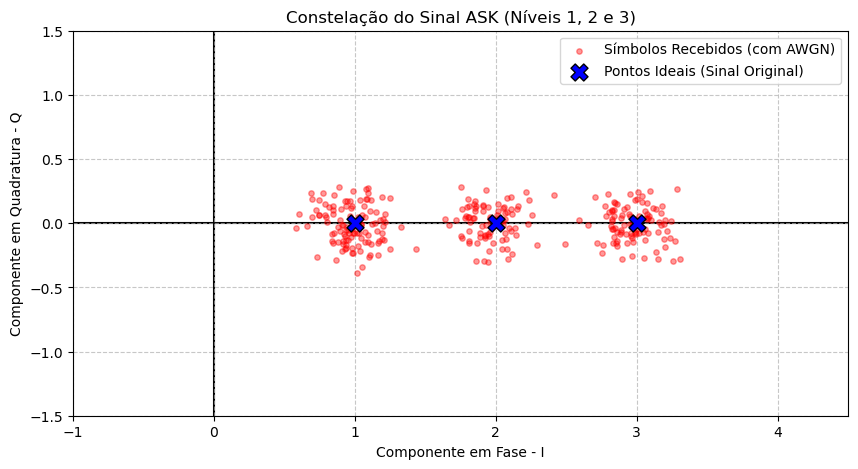

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definindo os símbolos ideais observados na imagem
# Como a fase não inverte, os valores são puramente reais (positivos)
amplitudes_ideais = np.array([1, 2, 3])

# 2. Simulando a transmissão de vários símbolos
num_simbolos = 300
# Sorteia aleatoriamente entre os níveis 1, 2 e 3 para criar o sinal transmitido
simbolos_tx = np.random.choice(amplitudes_ideais, num_simbolos)

# 3. Adicionando Ruído AWGN (Canal do mundo real)
# SNR define o quão espalhada ficará a nuvem. Tente alterar o valor do desvio padrão (0.15)
desvio_padrao = 0.15
ruido_I = np.random.normal(0, desvio_padrao, num_simbolos)
ruido_Q = np.random.normal(0, desvio_padrao, num_simbolos)
ruido_complexo = ruido_I + 1j * ruido_Q

# Sinal final recebido = Sinal ideal + Ruído
simbolos_rx = simbolos_tx + ruido_complexo

# 4. Plotando o Diagrama de Constelação
plt.figure(figsize=(10, 5))

# Plota os símbolos recebidos com ruído (a "nuvem")
plt.scatter(simbolos_rx.real, simbolos_rx.imag, color='red', alpha=0.4, s=15, label='Símbolos Recebidos (com AWGN)', zorder=2)

# Plota os pontos ideais extraídos da sua imagem
plt.scatter(amplitudes_ideais, np.zeros_like(amplitudes_ideais), color='blue', edgecolor='black', s=150, marker='X', label='Pontos Ideais (Sinal Original)', zorder=3)

# Configuração visual do plano complexo
plt.axhline(0, color='black', linewidth=1.5, zorder=1) # Eixo I
plt.axvline(0, color='black', linewidth=1.5, zorder=1) # Eixo Q

plt.title('Constelação do Sinal ASK (Níveis 1, 2 e 3)')
plt.xlabel('Componente em Fase - I')
plt.ylabel('Componente em Quadratura - Q')
plt.xlim(-1, 4.5)
plt.ylim(-1.5, 1.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()